# Data Augmentation

## Objective

The baseline models were trained using the original imbalanced dataset. Since the withdrawal class represents only a minority of students, the models may become biased toward predicting the majority class.

This notebook investigates whether different data augmentation techniques can improve the prediction of student withdrawal by increasing the representation of the minority class in the training data.

The following augmentation techniques are evaluated:

- Random Oversampling
- SMOTE
- ADASYN

The augmented models will later be compared with the baseline models using multiple evaluation metrics.

Import Libraries

In [27]:
import pandas as pd
import numpy as np

import joblib
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

Load Data

In [3]:
X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")

y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

Check Original Distribution

In [4]:
print("Original Training Distribution")
print(y_train.value_counts())
print()
print(y_train.value_counts(normalize=True))

Original Training Distribution
dropout_target
0    17949
1     8125
Name: count, dtype: int64

dropout_target
0    0.688387
1    0.311613
Name: proportion, dtype: float64


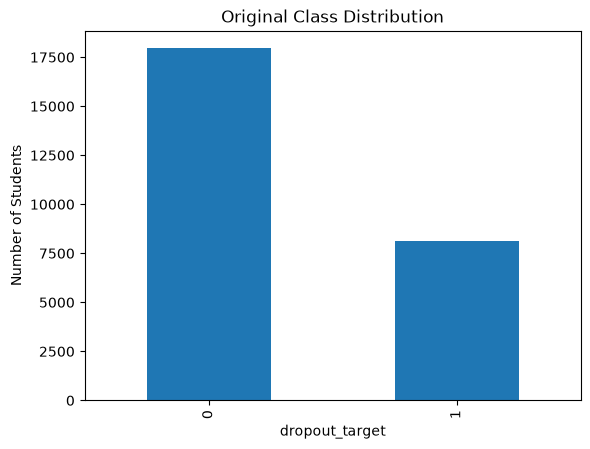

In [5]:
#Visulize
y_train.value_counts().plot(
    kind="bar",
    title="Original Class Distribution"
)

plt.ylabel("Number of Students")

plt.show()

Random Oversampling

dropout_target
0    17949
1    17949
Name: count, dtype: int64


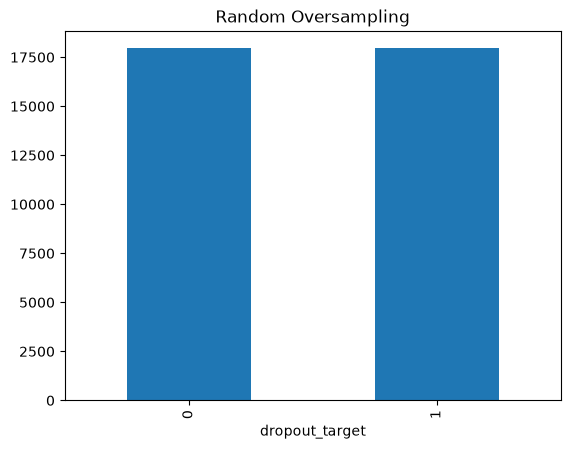

In [8]:
ros = RandomOverSampler(
    random_state=42
)

X_ros, y_ros = ros.fit_resample(
    X_train,
    y_train
)
print(y_ros.value_counts())

#plot
y_ros.value_counts().plot(
    kind="bar",
    title="Random Oversampling"
)
plt.show()


SMOTE

dropout_target
0    17949
1    17949
Name: count, dtype: int64


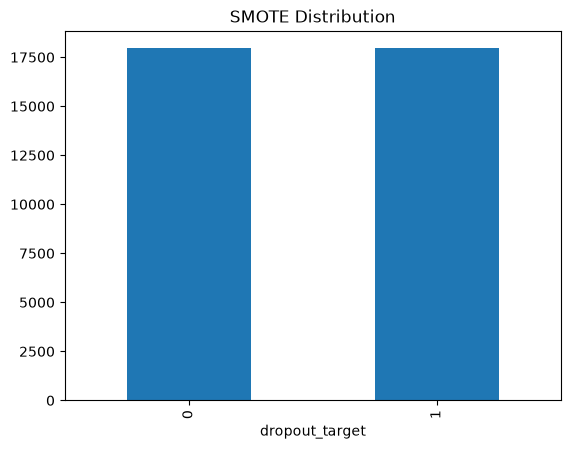

In [11]:
smote = SMOTE(
    random_state=42
)

X_smote, y_smote = smote.fit_resample(
    X_train,
    y_train
)
print(y_smote.value_counts())

#Plot
y_smote.value_counts().plot(
    kind="bar",
    title="SMOTE Distribution"
)

plt.show()

ADASYN

dropout_target
1    18155
0    17949
Name: count, dtype: int64


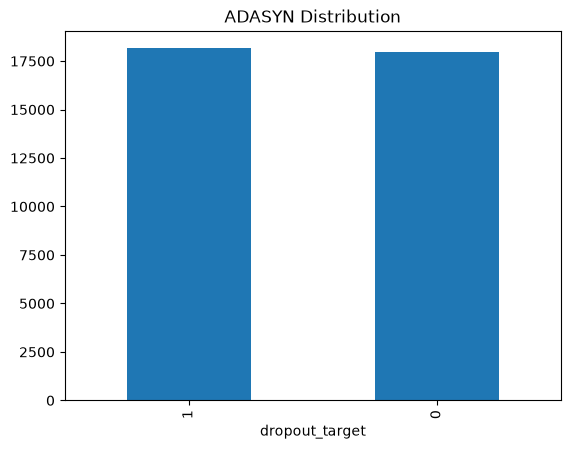

In [14]:
adasyn = ADASYN(
    random_state=42
)

X_ada, y_ada = adasyn.fit_resample(
    X_train,
    y_train
)
print(y_ada.value_counts())
#Plot
y_ada.value_counts().plot(
    kind="bar",
    title="ADASYN Distribution"
)

plt.show()

Evaluation Function

In [15]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]
    return {
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred),
        "Recall": recall_score(y_test,pred),
        "F1": f1_score(y_test,pred),
        "ROC_AUC": roc_auc_score(y_test,prob)
    }

Train Models on Random Oversampling

Logistic Regression

In [19]:
lr_ros = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_ros.fit(X_ros, y_ros)

lr_ros_result = evaluate(lr_ros, X_test, y_test)

Decision Tree

In [20]:
dt_ros = DecisionTreeClassifier(
    random_state=42
)

dt_ros.fit(X_ros, y_ros)

dt_ros_result = evaluate(dt_ros, X_test, y_test)

Random Forest

In [21]:
rf_ros = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf_ros.fit(X_ros, y_ros)

rf_ros_result = evaluate(rf_ros, X_test, y_test)

XGBoost

In [28]:
xgb_ros = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric="logloss"
)

xgb_ros.fit(X_ros, y_ros)

xgb_ros_result = evaluate(xgb_ros, X_test, y_test)

LightGBM

In [29]:
lgbm_ros = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)

lgbm_ros.fit(X_ros, y_ros)

lgbm_ros_result = evaluate(lgbm_ros, X_test, y_test)

[LightGBM] [Info] Number of positive: 17949, number of negative: 17949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005977 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4187
[LightGBM] [Info] Number of data points in the train set: 35898, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

SMOTE Models

Logistic Regression

In [30]:
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_smote.fit(X_smote, y_smote)
lr_smote_result = evaluate(lr_smote, X_test, y_test)

Decision Tree

In [31]:
dt_smote = DecisionTreeClassifier(
    random_state=42
)
dt_smote.fit(X_smote, y_smote)
dt_smote_result = evaluate(dt_smote, X_test, y_test)

Random Forest

In [32]:
rf_smote = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)
rf_smote.fit(X_smote, y_smote)
rf_smote_result = evaluate(rf_smote, X_test, y_test)

XGBoost

In [33]:
xgb_smote = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric="logloss"
)
xgb_smote.fit(X_smote, y_smote)
xgb_smote_result = evaluate(xgb_smote, X_test, y_test)

LightGBM

In [34]:
lgbm_smote = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)
lgbm_smote.fit(X_smote, y_smote)
lgbm_smote_result = evaluate(lgbm_smote, X_test, y_test)

[LightGBM] [Info] Number of positive: 17949, number of negative: 17949
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18584
[LightGBM] [Info] Number of data points in the train set: 35898, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

ADASYN Models

Logistic Regression

In [35]:
lr_ada = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_ada.fit(X_ada, y_ada)
lr_ada_result = evaluate(lr_ada, X_test, y_test)

Decision Tree

In [36]:
dt_ada = DecisionTreeClassifier(
    random_state=42
)
dt_ada.fit(X_ada, y_ada)
dt_ada_result = evaluate(dt_ada, X_test, y_test)

Random Forest

In [37]:
rf_ada = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)
rf_ada.fit(X_ada, y_ada)
rf_ada_result = evaluate(rf_ada, X_test, y_test)

XGBoost

In [38]:
xgb_ada = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric="logloss"
)
xgb_ada.fit(X_ada, y_ada)
xgb_ada_result = evaluate(xgb_ada, X_test, y_test)

LightGBM

In [39]:
lgbm_ada = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)
lgbm_ada.fit(X_ada, y_ada)
lgbm_ada_result = evaluate(lgbm_ada, X_test, y_test)

[LightGBM] [Info] Number of positive: 18155, number of negative: 17949
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18717
[LightGBM] [Info] Number of data points in the train set: 36104, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502853 -> initscore=0.011412
[LightGBM] [Info] Start training from score 0.011412
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

Comparison

In [40]:
comparison = pd.DataFrame([
    # Random Oversampling
    ["Random Oversampling", "Logistic Regression", *lr_ros_result.values()],
    ["Random Oversampling", "Decision Tree", *dt_ros_result.values()],
    ["Random Oversampling", "Random Forest", *rf_ros_result.values()],
    ["Random Oversampling", "XGBoost", *xgb_ros_result.values()],
    ["Random Oversampling", "LightGBM", *lgbm_ros_result.values()],

    # SMOTE
    ["SMOTE", "Logistic Regression", *lr_smote_result.values()],
    ["SMOTE", "Decision Tree", *dt_smote_result.values()],
    ["SMOTE", "Random Forest", *rf_smote_result.values()],
    ["SMOTE", "XGBoost", *xgb_smote_result.values()],
    ["SMOTE", "LightGBM", *lgbm_smote_result.values()],

    # ADASYN
    ["ADASYN", "Logistic Regression", *lr_ada_result.values()],
    ["ADASYN", "Decision Tree", *dt_ada_result.values()],
    ["ADASYN", "Random Forest", *rf_ada_result.values()],
    ["ADASYN", "XGBoost", *xgb_ada_result.values()],
    ["ADASYN", "LightGBM", *lgbm_ada_result.values()]

], columns=[
    "Augmentation",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
])

comparison.sort_values(
    by="F1",
    ascending=False
)

,Augmentation,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Random Oversampling,XGBoost,0.828348,0.722006,0.730182,0.726071,0.870681
4,Random Oversampling,LightGBM,0.824053,0.708687,0.739045,0.723548,0.872048
8,SMOTE,XGBoost,0.838319,0.784508,0.663220,0.718783,0.871592
7,SMOTE,Random Forest,0.835558,0.771671,0.670606,0.717597,0.870915
12,ADASYN,Random Forest,0.833410,0.767402,0.667651,0.714060,0.871593
9,SMOTE,LightGBM,0.835558,0.779266,0.658789,0.713981,0.871225
2,Random Oversampling,Random Forest,0.834177,0.772989,0.662235,0.713339,0.868851
13,ADASYN,XGBoost,0.834177,0.776807,0.656327,0.711503,0.869429
14,ADASYN,LightGBM,0.833257,0.776671,0.652388,0.709125,0.870239
0,Random Oversampling,Logistic Regression,0.785703,0.631864,0.747907,0.685006,0.845202
